In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding = "latin1")

# Table of Contents

- [Data Overview](#data-overview)
  - [Data Exploration](#data-exploration)
  - [Data Cleaning and Preprocessing](#data-cleaning-and-preprocessing)
  - [Identifying Outliers](#identifying-outliers)

- [Sales Trend Analysis](#sales-trend-analysis)
  - [Time Series Analysis](#time-series-analysis)
  - [Best-Selling Products and Categories](#best-selling-products-and-categories)
  - [Profitability Analysis of Best-Sellers](#profitability-analysis-of-best-sellers)
  - [Geographic Sales Performance](#geographic-sales-performance)

- [Customer Segmentation Using RFM Analysis](#customer-segmentation-using-rfm-analysis)

- [Sales Forecasting Using Time Series Analysis](#sales-forecasting-using-time-series-analysis)

# Data Overview

## Data Exploration

In [58]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Day,Order month_year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,1,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820,11,2016,1,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714,6,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,6,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,6,2015-10


In [59]:
df.shape

(9994, 25)

In [60]:
df.dtypes

Row ID                       int64
Order ID                    object
Order Date          datetime64[ns]
Ship Date           datetime64[ns]
Ship Mode                   object
Customer ID                 object
Customer Name               object
Segment                     object
Country                     object
City                        object
State                       object
Postal Code                  int64
Region                      object
Product ID                  object
Category                    object
Sub-Category                object
Product Name                object
Sales                      float64
Quantity                     int64
Discount                   float64
Profit                     float64
Order Month                  int32
Order Year                   int32
Order Day                    int32
Order month_year         period[M]
dtype: object

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9994 non-null   int64         
 1   Order ID          9994 non-null   object        
 2   Order Date        9994 non-null   datetime64[ns]
 3   Ship Date         9994 non-null   datetime64[ns]
 4   Ship Mode         9994 non-null   object        
 5   Customer ID       9994 non-null   object        
 6   Customer Name     9994 non-null   object        
 7   Segment           9994 non-null   object        
 8   Country           9994 non-null   object        
 9   City              9994 non-null   object        
 10  State             9994 non-null   object        
 11  Postal Code       9994 non-null   int64         
 12  Region            9994 non-null   object        
 13  Product ID        9994 non-null   object        
 14  Category          9994 n

In [62]:
df[["Sales", "Quantity", "Discount","Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


In [63]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

In [64]:
# Chacking for nulls
df.isna().sum()

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Country             0
City                0
State               0
Postal Code         0
Region              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Order Month         0
Order Year          0
Order Day           0
Order month_year    0
dtype: int64

In [10]:
df["Country"].unique()

array(['United States'], dtype=object)

In [11]:
df["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [12]:
pd.set_option('display.max_colwidth',None)

In [13]:
df.groupby(by = "Category")["Sub-Category"].unique()

Category
Furniture                                                    [Bookcases, Chairs, Tables, Furnishings]
Office Supplies    [Labels, Storage, Art, Binders, Appliances, Paper, Envelopes, Fasteners, Supplies]
Technology                                                   [Phones, Accessories, Machines, Copiers]
Name: Sub-Category, dtype: object

## Data Cleaning and Preprocessing

In [14]:
# Converting date columns to datetime data type

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [16]:
df["Order Month"] = df["Order Date"].dt.month
df["Order Year"] = df["Order Date"].dt.year
df["Order Day"] = df["Order Date"].dt.dayofweek
df["Order month_year"] = df['Order Date'].dt.to_period('M')

In [17]:
df["Order month_year"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 9994 entries, 0 to 9993
Series name: Order month_year
Non-Null Count  Dtype    
--------------  -----    
9994 non-null   period[M]
dtypes: period[M](1)
memory usage: 78.2 KB


In [18]:
df.to_csv("superstore_cleaned.csv", index = False)

## Identifying Outliers

In [19]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outlier = df[(df['Sales'] < lower_fence) | (df['Sales'] > upper_fence)]
print(f"Number of outliers: {outlier.shape[0]}")

Number of outliers: 1167


In [20]:
Q1 = df['Profit'].quantile(0.25)
Q3 = df['Profit'].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outlier = df[(df['Profit'] < lower_fence) | (df['Profit'] > upper_fence)]
print(f"Number of outliers: {outlier.shape[0]}")

Number of outliers: 1881


As we can seee there are huge amount of outliers, but for e-commerce sales data it is very common because sales distributions are heavily right-skewed.

# Sales Trend Analysis

### Time Series Analysis

In [21]:
df.groupby(by = ["Order Year", "Order Month"])["Sales"].sum()

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

In [22]:
# Best Performing Months
df.groupby(by = "Order month_year")["Sales"].sum().sort_values(ascending = False)[:3].reset_index()

,Order month_year,Sales
0,2017-11,118447.825
1,2016-12,96999.043
2,2017-09,87866.652


In [23]:
# Worst performing Months
df.groupby(by = "Order month_year")["Sales"].sum().sort_values().head(3).reset_index()

,Order month_year,Sales
0,2014-02,4519.892
1,2015-02,11951.411
2,2014-01,14236.895


In [24]:
# Peak sales months
df.groupby(by = "Order Month")["Sales"].sum().sort_values(ascending = False)[:3].reset_index()

,Order Month,Sales
0,11,352461.0710
1,12,325293.5035
2,9,307649.9457


In [25]:
# Low sales months
df.groupby(by = "Order Month")["Sales"].sum().sort_values()[:3].reset_index()

,Order Month,Sales
0,2,59751.2514
1,1,94924.8356
2,4,137762.1286


Seasonal Pattern: Sales tend to decline during the first four months of the year and peak toward the end of the year, likely driven by holiday-season demand.

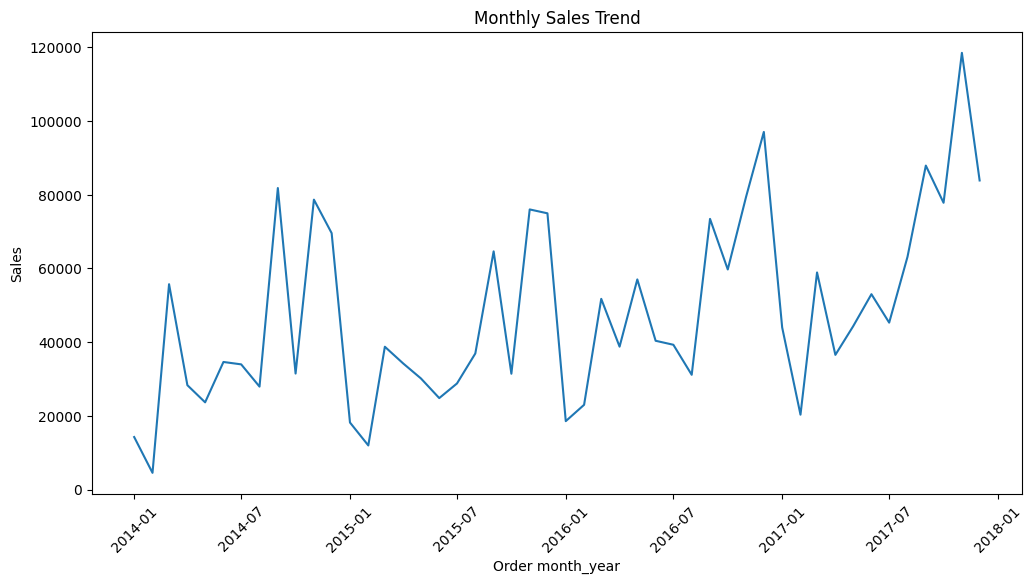

In [26]:
# Monthly Sales Trend on a line chart

plt.figure(figsize = (12,6))
monthly_sales = df.groupby('Order month_year')['Sales'].sum().reset_index()

monthly_sales["Order month_year"] = monthly_sales["Order month_year"].dt.to_timestamp()

sns.lineplot(x= "Order month_year", y= "Sales", data= monthly_sales,errorbar= None)
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.show()

In [27]:
# Yearly Sales
df.groupby(by = "Order Year")["Sales"].sum().round(2).reset_index()

,Order Year,Sales
0,2014,484247.50
1,2015,470532.51
2,2016,609205.60
3,2017,733215.26


After a minor dip in 2015, sales grew significantly in 2016 and 2017, indicating a sustained upward trend over the latter years.

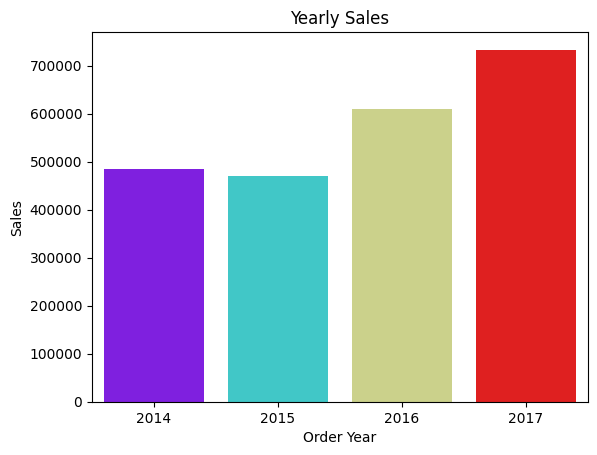

In [28]:
# Yearly sales on bar chart

sns.barplot(data = df, x = "Order Year", y = "Sales", estimator = "sum", hue = "Order Year", palette = "rainbow", legend = False, errorbar = None)
plt.title("Yearly Sales")
plt.show()

### Best-Selling Products and Categories

In [29]:
df.groupby("Category")["Sales"].sum().sort_values(ascending = False).round(2).reset_index()

,Category,Sales
0,Technology,836154.03
1,Furniture,741999.80
2,Office Supplies,719047.03


Technology generates the highest revenue among the three categories. However, the Furniture and Office Supplies categories also contribute significantly to overall sales, with revenues not far behind Technology.

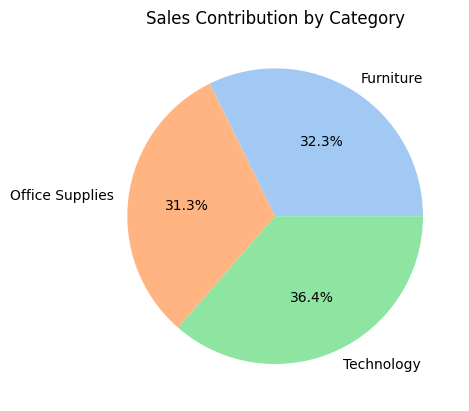

In [30]:
# Visualizing Sales Contribution by Category
data = df.groupby("Category")["Sales"].sum()
colors = sns.color_palette(palette = 'pastel', n_colors = len(data))
plt.pie(data, colors = colors, labels = data.index, autopct='%1.1f%%')
plt.title("Sales Contribution by Category")
plt.show()

In [31]:
# Sales by Sub-Category
df.groupby(["Category", "Sub-Category"])[["Sales"]].sum().sort_values(by = "Sales", ascending = False).reset_index()

,Category,Sub-Category,Sales
0,Technology,Phones,330007.0540
1,Furniture,Chairs,328449.1030
2,Office Supplies,Storage,223843.6080
3,Furniture,Tables,206965.5320
4,Office Supplies,Binders,203412.7330
5,Technology,Machines,189238.6310
6,Technology,Accessories,167380.3180
7,Technology,Copiers,149528.0300
8,Furniture,Bookcases,114879.9963
9,Office Supplies,Appliances,107532.1610


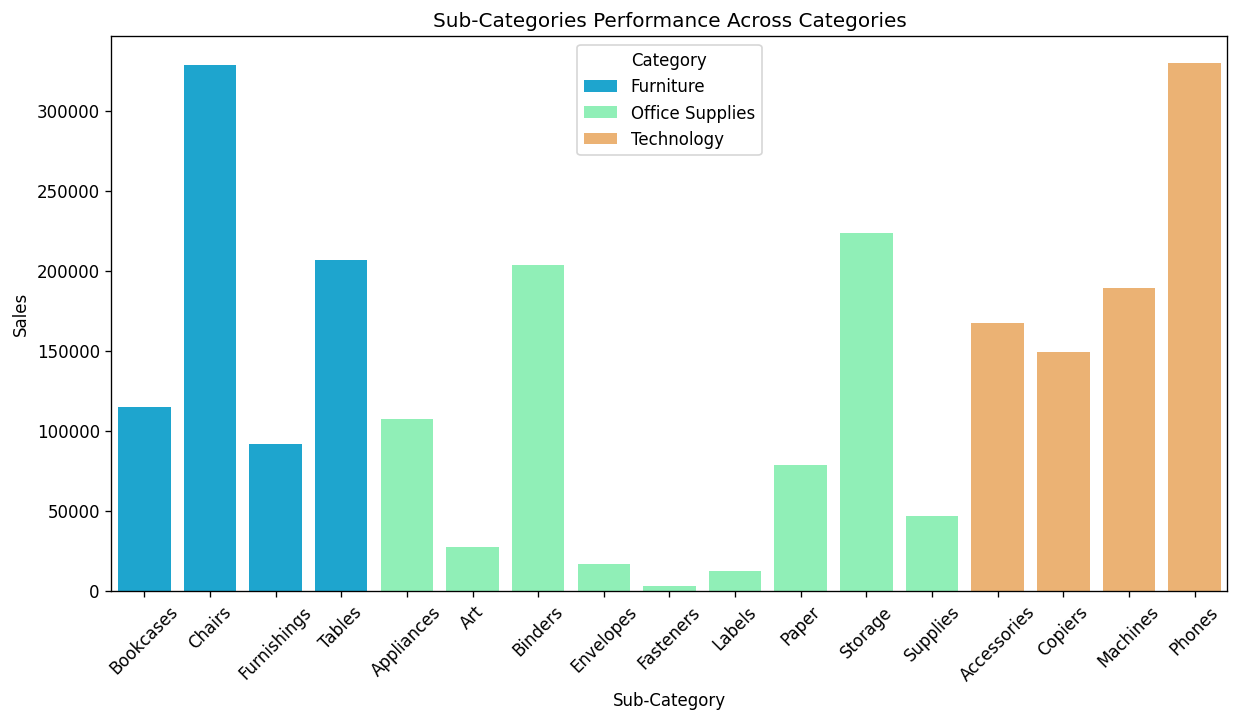

In [32]:
# Visualizing Sub-Categories Performance Across Categories
data = df.groupby(["Category","Sub-Category"])["Sales"].sum().reset_index()

plt.figure(figsize = (12,6), dpi = 120)
sns.barplot(data = data, hue = "Category", y = "Sales", x = "Sub-Category", palette = "rainbow")
plt.title("Sub-Categories Performance Across Categories")
plt.xticks(rotation = 45)
plt.show()

In [33]:
# Category-wise Top Selling Sub-Category

df2 = df.groupby(["Category", "Sub-Category"], as_index=False)["Sales"].sum()
max_sales = df2.groupby("Category")["Sales"].transform("max")
df2[df2["Sales"] == max_sales].sort_values(by = "Sales", ascending = False, ignore_index= True)

,Category,Sub-Category,Sales
0,Technology,Phones,330007.054
1,Furniture,Chairs,328449.103
2,Office Supplies,Storage,223843.608


In [34]:
# Category-wise Least Selling Sub-Category

df2 = df.groupby(["Category", "Sub-Category"], as_index=False)["Sales"].sum()
min_sales = df2.groupby("Category")["Sales"].transform("min")
df2[df2["Sales"] == min_sales].sort_values(by = "Sales", ascending = False, ignore_index= True)

,Category,Sub-Category,Sales
0,Technology,Copiers,149528.030
1,Furniture,Furnishings,91705.164
2,Office Supplies,Fasteners,3024.280


In [35]:
# Sales by Quantity
df.groupby("Category")["Quantity"].sum().sort_values(ascending = False).reset_index()

,Category,Quantity
0,Office Supplies,22906
1,Furniture,8028
2,Technology,6939


While Office Supplies is the most demanded category in terms of units sold, Technology generates the highest revenue. This suggests that Technology products have a higher average sales value per unit, whereas Office Supplies benefits from high purchase frequency and volume.

In [36]:
# Subcategory-wise Sales Volume
df.groupby(["Category", "Sub-Category"])[["Quantity"]].sum().sort_values(by = "Quantity", ascending = False).reset_index()

,Category,Sub-Category,Quantity
0,Office Supplies,Binders,5974
1,Office Supplies,Paper,5178
2,Furniture,Furnishings,3563
3,Technology,Phones,3289
4,Office Supplies,Storage,3158
5,Office Supplies,Art,3000
6,Technology,Accessories,2976
7,Furniture,Chairs,2356
8,Office Supplies,Appliances,1729
9,Office Supplies,Labels,1400


In [37]:
# Most selling Sub-Category in Each Category
df3 = df.groupby(["Category", "Sub-Category"], as_index = False)["Quantity"].sum()
df3.loc[df3.groupby("Category")["Quantity"].idxmax()].sort_values(by = "Quantity", ascending = False, ignore_index = True)

,Category,Sub-Category,Quantity
0,Office Supplies,Binders,5974
1,Furniture,Furnishings,3563
2,Technology,Phones,3289


In [38]:
# Least selling Sub-Category in Each Category
df3 = df.groupby(["Category", "Sub-Category"], as_index = False)["Quantity"].sum()
df3.loc[df3.groupby("Category")["Quantity"].idxmax()].sort_values(by = "Quantity", ascending = False, ignore_index = True)

,Category,Sub-Category,Quantity
0,Office Supplies,Binders,5974
1,Furniture,Furnishings,3563
2,Technology,Phones,3289


In [39]:
#Top 10 products by Revenue Contribution
df.groupby(['Category','Product Name'])['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

,Category,Product Name,Sales
0,Technology,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
2,Technology,Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
3,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,Office Supplies,GBC DocuBind TL300 Electric Binding System,19823.479
5,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Technology,Hewlett Packard LaserJet 3310 Copier,18839.686
7,Technology,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
8,Office Supplies,GBC DocuBind P400 Electric Binding System,17965.068
9,Office Supplies,High Speed Automatic Electric Letter Opener,17030.312


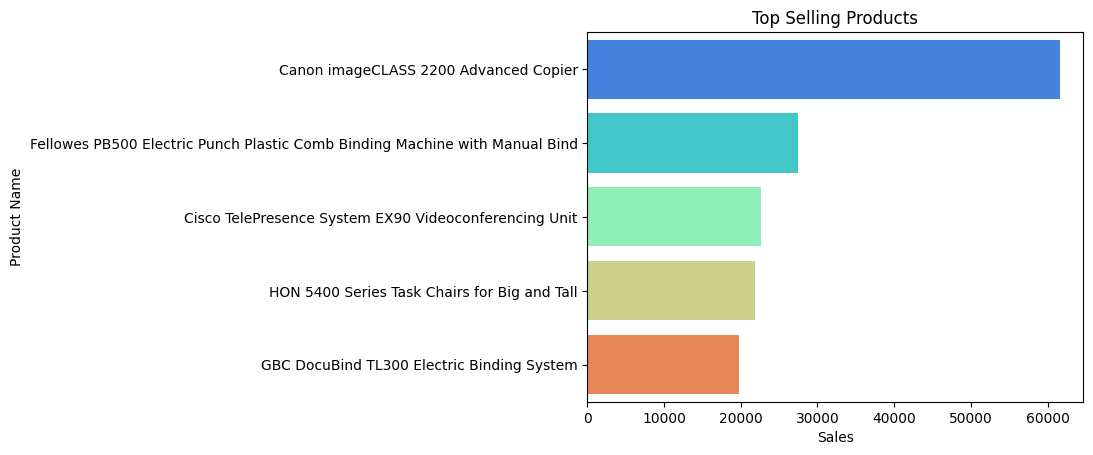

In [40]:
# Top selling Products

top_5 = df.groupby('Product Name')['Sales'].sum().sort_values(ascending = False).head(5).reset_index()

sns.barplot(data = top_5, x = 'Sales', y = 'Product Name', hue = 'Product Name', palette = 'rainbow', legend = False)
plt.title("Top Selling Products")
plt.show()

In [41]:
# Top 10 products by Sales Volume
df.groupby(['Category','Product Name'])['Quantity'].sum().sort_values( ascending=False).head(10).reset_index()

,Category,Product Name,Quantity
0,Office Supplies,Staples,215
1,Office Supplies,Staple envelope,170
2,Office Supplies,Easy-staple paper,150
3,Office Supplies,Staples in misc. colors,86
4,Furniture,KI Adjustable-Height Table,74
5,Office Supplies,Storex Dura Pro Binders,71
6,Office Supplies,Avery Non-Stick Binders,71
7,Office Supplies,GBC Premium Transparent Covers with Diagonal Lined Pattern,67
8,Furniture,"Situations Contoured Folding Chairs, 4/Set",64
9,Furniture,Staple-based wall hangings,62


In [42]:
# Monthly Revenue Trend Across Categories
df.groupby(['Order Month', 'Category'])[['Sales']].sum().sort_values(by=['Category', 'Sales'], ascending=False).reset_index()

,Order Month,Category,Sales
0,11,Technology,131134.8410
1,12,Technology,100832.8920
2,9,Technology,99380.7090
3,3,Technology,97851.5700
4,10,Technology,87031.9450
5,5,Technology,63642.1550
6,7,Technology,54854.0260
7,8,Technology,52025.8560
8,6,Technology,48304.5830
9,4,Technology,47630.2750


All categories exhibit a similar seasonal pattern, with lower sales at the beginning of the year and higher sales during the year-end holiday season.

In [43]:
# Category-wise sales growth
pd.pivot_table(data= df, columns= 'Order Year', index='Category', values= 'Sales', aggfunc = 'sum')

Order Year,2014,2015,2016,2017
Category,,,,
Furniture,157192.8531,170518.237,198901.436,215387.2692
Office Supplies,151776.4120,137233.463,183939.982,246097.1750
Technology,175278.2330,162780.809,226364.180,271730.8110


Office Supplies recorded the highest growth (62%), followed by Technology (55%) and Furniture (37%). Despite strong growth across all categories, Technology remained the highest revenue-generating category throughout the period.

### Profitability Analysis of Best-Sellers

In [44]:
product_profitability = (df.groupby(['Category', 'Product Name']).agg({'Sales': 'sum','Profit': 'sum','Discount': 'mean'}).round(2).reset_index())

product_profitability['Profit Margin %'] = ((product_profitability['Profit'] / product_profitability['Sales']) * 100).round(2)

product_profitability.sort_values(by='Sales',ascending=False).head(10)

,Category,Product Name,Sales,Profit,Discount,Profit Margin %
1494,Technology,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,0.12,40.91
775,Office Supplies,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04,0.24,28.24
1513,Technology,Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08,0.50,-8.00
206,Furniture,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,0.20,0.00
804,Office Supplies,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,0.30,11.27
806,Office Supplies,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,0.52,4.00
1556,Technology,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,0.20,37.07
1549,Technology,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98,0.17,22.29
801,Office Supplies,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,0.45,-10.45
857,Office Supplies,High Speed Automatic Electric Letter Opener,17030.31,-262.00,0.07,-1.54


Products with moderate discounts (12-20%) generally maintained strong profit margins of 22-41%, whereas heavily discounted products (45-52%) often generated very low or negative margins, highlighting the impact of discounting on profitability.

## Geographic Sales Performance

In [45]:
# Sales by Region
df.groupby('Region')['Sales'].sum().sort_values(ascending = False).reset_index()

,Region,Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


In [46]:
# Sales by State
df.groupby('State')['Sales'].sum().sort_values(ascending = False).reset_index()

,State,Sales
0,California,457687.6315
1,New York,310876.2710
2,Texas,170188.0458
3,Washington,138641.2700
4,Pennsylvania,116511.9140
5,Florida,89473.7080
6,Illinois,80166.1010
7,Ohio,78258.1360
8,Michigan,76269.6140
9,Virginia,70636.7200


In [47]:
# Top Performing Cities
df.groupby('City')[['Sales','Quantity']].sum().sort_values(by = 'Sales', ascending = False).head(10).reset_index()

,City,Sales,Quantity
0,New York City,256368.1610,3417
1,Los Angeles,175851.3410,2879
2,Seattle,119540.7420,1590
3,San Francisco,112669.0920,1935
4,Philadelphia,109077.0130,1981
5,Houston,64504.7604,1466
6,Chicago,48539.5410,1132
7,San Diego,47521.0290,670
8,Jacksonville,44713.1830,429
9,Springfield,43054.3420,649


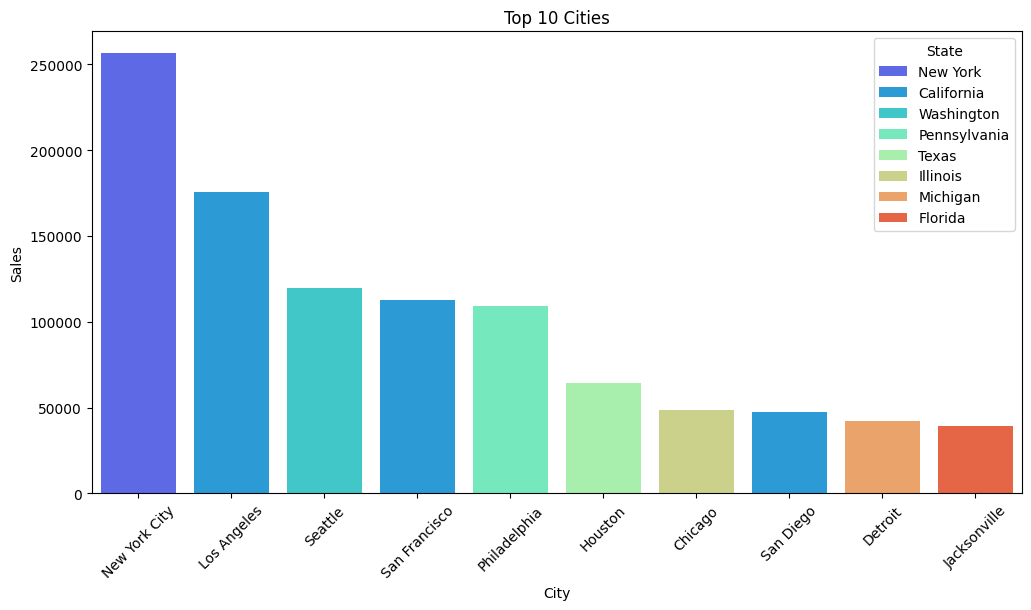

In [48]:
# Top 10 cities by Sales visualization

data = df.groupby(["City","State"])["Sales"].sum().sort_values(ascending = False).head(10).reset_index()

plt.figure(figsize = (12,6))
sns.barplot(data = data, hue = "State", y = "Sales", x = "City", palette = "rainbow")
plt.title("Top 10 Cities")
plt.xticks(rotation = 45)
plt.show()

In [49]:
# Bottom 10 cities by sales
df.groupby('City')[['Sales','Quantity']].sum().sort_values(by = 'Sales').head(10).reset_index()

,City,Sales,Quantity
0,Abilene,1.392,2
1,Elyria,1.824,1
2,Jupiter,2.064,1
3,Pensacola,2.214,3
4,Ormond Beach,2.808,3
5,San Luis Obispo,3.620,2
6,Springdale,4.300,2
7,Layton,4.960,4
8,Keller,6.000,2
9,Missouri City,6.370,7


In [50]:
# Bottom 10 cities by Number of Customers
df.groupby('State')['Customer ID'].nunique().sort_values().head(10).reset_index(name = 'Total Customers')

,State,Total Customers
0,Wyoming,1
1,North Dakota,2
2,West Virginia,2
3,Maine,3
4,District of Columbia,4
5,Vermont,5
6,South Dakota,5
7,Montana,8
8,Idaho,11
9,Kansas,14


In [51]:
# Customer Repeat Pattern by State

# Total customers per state
total_customers = df.groupby('State')['Customer ID'].nunique().reset_index(name='Total Customers')


# Repeat customers per state
repeat_customers = df.groupby(['State', 'Customer ID'])['Order ID'].nunique().reset_index(name='Total Orders')

repeat_customers = repeat_customers[repeat_customers['Total Orders'] > 1]

repeat_by_state = repeat_customers.groupby('State')['Customer ID'].nunique().reset_index(name='Repeat Customers')

# Merge
retention_analysis = total_customers.merge(repeat_by_state,on='State',how='left')

# Fill NaN
retention_analysis['Repeat Customers'] = retention_analysis['Repeat Customers'].fillna(0)

# Customer Repeat rate %
retention_analysis['Customer Repeat Rate %'] = ((retention_analysis['Repeat Customers'] /retention_analysis['Total Customers']) * 100).round(2)

# Sort
retention_analysis.sort_values(by='Customer Repeat Rate %',ascending=False, ignore_index = True)

,State,Total Customers,Repeat Customers,Customer Repeat Rate %
0,California,577,294.0,50.95
1,New York,415,121.0,29.16
2,Texas,370,103.0,27.84
3,Vermont,5,1.0,20.00
4,Illinois,237,38.0,16.03
5,Ohio,202,29.0,14.36
6,Washington,224,28.0,12.50
7,North Carolina,122,14.0,11.48
8,Pennsylvania,257,29.0,11.28
9,Michigan,106,11.0,10.38


In [52]:
# Best performing products by State

state_subcategory = df.groupby(['State', 'Sub-Category'])['Sales'].sum().reset_index()

state_subcategory.loc[state_subcategory.groupby('State')['Sales'].idxmax()].sort_values(by='Sales', ascending=False, ignore_index = True)

,State,Sub-Category,Sales
0,California,Phones,67964.536
1,New York,Phones,47502.620
2,Texas,Phones,28589.568
3,Washington,Tables,25062.320
4,Florida,Machines,24573.940
5,Michigan,Binders,22821.970
6,Pennsylvania,Phones,19702.404
7,Indiana,Copiers,18499.930
8,Illinois,Phones,16771.784
9,Ohio,Phones,14634.948


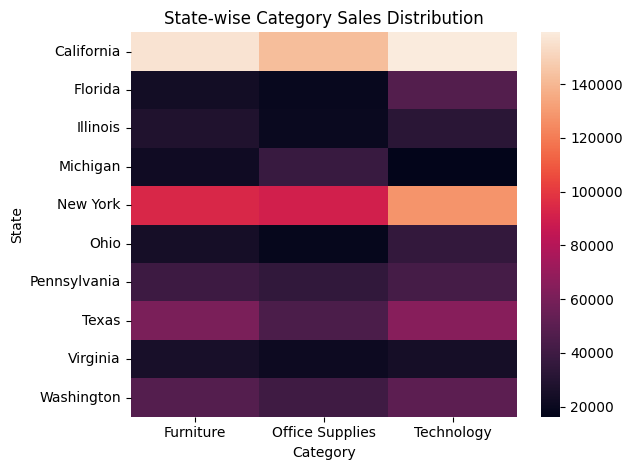

In [53]:
# State-wise Category Sales Heatmap

# Top 10 states by sales
top_10_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10).index.tolist()

# Filtering the dataframe
filtered_df = df[df['State'].isin(top_10_states)]

# Creating a pivot table
pivot = pd.pivot_table(filtered_df, columns = 'Category', index = 'State', values = 'Sales', aggfunc = 'sum')

sns.heatmap(pivot)
plt.title('State-wise Category Sales Distribution')
plt.tight_layout()
plt.show()

New York, California, and Texas generate the highest sales and maintain repeat purchase rates above 25%, indicating strong customer loyalty and brand presence in these major urban markets.

# Customer Segmentation Using RFM Analysis

In [54]:
# Recency
last_purchase_date = df.groupby('Customer ID')['Order Date'].max()

reference_date = df['Order Date'].max()

recency = (reference_date - last_purchase_date).dt.days.reset_index(name = 'Recency')

# Frequency
frequency = df.groupby('Customer ID')['Order Date'].count().reset_index(name = 'Frequency')

# Monetary
monetary = df.groupby('Customer ID')['Sales'].sum().round(2).reset_index(name = 'Monetary')


rfm = recency.merge(frequency, on = 'Customer ID')
rfm = rfm.merge(monetary, on = 'Customer ID')
rfm

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,11,5563.56
1,AA-10375,19,15,1056.39
2,AA-10480,259,12,1790.51
3,AA-10645,55,18,5086.93
4,AB-10015,415,6,886.16
...,...,...,...,...
788,XP-21865,43,28,2374.66
789,YC-21895,4,8,5454.35
790,YS-21880,9,12,6720.44
791,ZC-21910,54,31,8025.71


In [85]:
# Calculating rfm score

rfm['Recency Score'] = pd.qcut(rfm['Recency'], 5,labels=[5,4,3,2,1])

rfm['Frequency Score'] = pd.qcut(rfm['Frequency'], 5, labels=[1,2,3,4,5])

rfm['Monetary Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm

,Customer ID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetary Score,Segment,Profit
0,AA-10315,184,11,5563.56,2,3,5,At Risk,-362.8825
1,AA-10375,19,15,1056.39,5,4,2,Loyal,277.3824
2,AA-10480,259,12,1790.51,1,3,3,At Risk,435.8274
3,AA-10645,55,18,5086.93,3,4,5,At Risk,857.8033
4,AB-10015,415,6,886.16,1,1,1,Lost,129.3465
...,...,...,...,...,...,...,...,...,...
788,XP-21865,43,28,2374.66,4,5,3,Loyal,621.2300
789,YC-21895,4,8,5454.35,5,2,5,Potential Loyalists,1305.6290
790,YS-21880,9,12,6720.44,5,3,5,Potential Loyalists,1778.2923
791,ZC-21910,54,31,8025.71,3,5,5,At Risk,-1032.1490


In [56]:
# Coverting the scores to integers
rfm['Recency Score'] = rfm['Recency Score'].astype(int)
rfm['Frequency Score'] = rfm['Frequency Score'].astype(int)
rfm['Monetary Score'] = rfm['Monetary Score'].astype(int)

In [65]:
# RFM Segmentation

def segment_customer(row):
    if row['Recency Score'] >= 4 and row['Frequency Score'] >= 4 and row['Monetary Score'] >= 4:
        return 'High-Value'
    elif row['Recency Score'] >=4 and row['Frequency Score'] <=3 and row['Monetary Score'] >= 4:
        return 'Potential Loyalists'
    elif row['Recency Score'] >=4 and row['Frequency Score'] >=4 and row['Monetary Score'] <=3:
        return 'Loyal' 
    elif row['Recency Score'] <= 2 and row['Frequency Score'] >= 4 and row['Monetary Score'] >= 4:
        return 'Churned Loyal'
    elif row['Recency Score'] <= 3 and row['Frequency Score'] >=3 and row['Monetary Score'] >=3:
        return 'At Risk'
    elif row['Recency Score'] <=2 and row['Frequency Score'] <= 2 and row['Monetary Score'] <= 2:
        return 'Lost'
    elif row['Recency Score'] >=4 and row['Frequency Score'] == 1 and row['Monetary Score'] == 1:
        return 'New'
    elif row['Recency Score'] <= 3 and row['Frequency Score'] <= 3 and row['Monetary Score'] >= 4:
        return 'Dormant High Value'
    elif row['Recency Score'] <=3 and row['Frequency Score'] >= 4 and row['Monetary Score'] <= 3:
        return 'Churned Frequent'
    else:
        return 'Other'
        
rfm['Segment'] = rfm.apply(segment_customer, axis= 1)
rfm

,Customer ID,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetary Score,Segment
0,AA-10315,184,11,5563.56,2,3,5,At Risk
1,AA-10375,19,15,1056.39,5,4,2,Loyal
2,AA-10480,259,12,1790.51,1,3,3,At Risk
3,AA-10645,55,18,5086.93,3,4,5,At Risk
4,AB-10015,415,6,886.16,1,1,1,Lost
...,...,...,...,...,...,...,...,...
788,XP-21865,43,28,2374.66,4,5,3,Loyal
789,YC-21895,4,8,5454.35,5,2,5,Potential Loyalists
790,YS-21880,9,12,6720.44,5,3,5,Potential Loyalists
791,ZC-21910,54,31,8025.71,3,5,5,At Risk


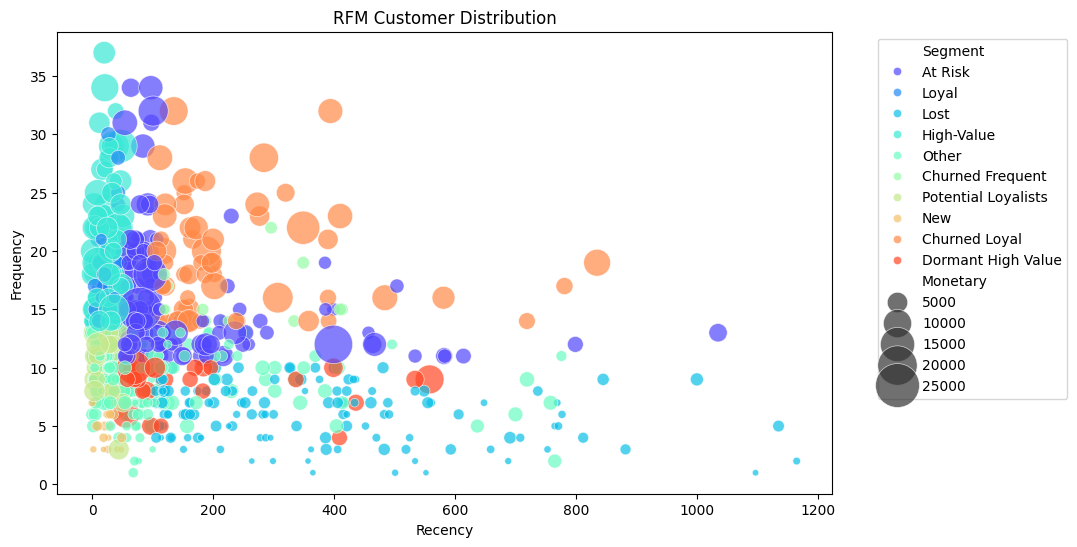

In [66]:
# RFM Customer Distribution Scatter Chart

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Frequency',
    size='Monetary',
    hue = 'Segment',
    palette = 'rainbow',
    sizes=(20, 1000),
    alpha=0.7
)

plt.title('RFM Customer Distribution')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

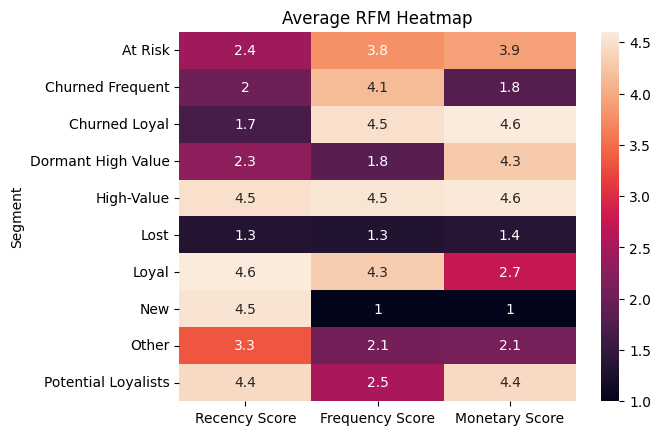

In [67]:
# Heatmap demonstarting the relationship between RFM scores and customer segments 
heatmap_data = rfm.groupby('Segment')[['Recency Score', 'Frequency Score', 'Monetary Score']].mean()

sns.heatmap(heatmap_data, annot = True)
plt.title('Average RFM Heatmap')
plt.show()

In [68]:
# Adding profit column to the RFM data
customer_profit = df.groupby('Customer ID')['Profit'].sum().reset_index(name = 'Profit')

rfm = rfm.merge(customer_profit, on = 'Customer ID')

In [69]:
# Segment Distribution
rfm['Segment'].value_counts().reset_index()

,Segment,count
0,Other,202
1,At Risk,130
2,Lost,126
3,High-Value,106
4,Churned Loyal,60
5,Loyal,53
6,Potential Loyalists,42
7,Dormant High Value,28
8,New,25
9,Churned Frequent,21


Over 300 customers fall into the At Risk, Lost, Churned Loyal, Dormant High Value, and Churned Frequent segments, highlighting a significant long-term retention challenge. However, the presence of 106 High-Value customers demonstrates that successful customer retention can be highly profitable.

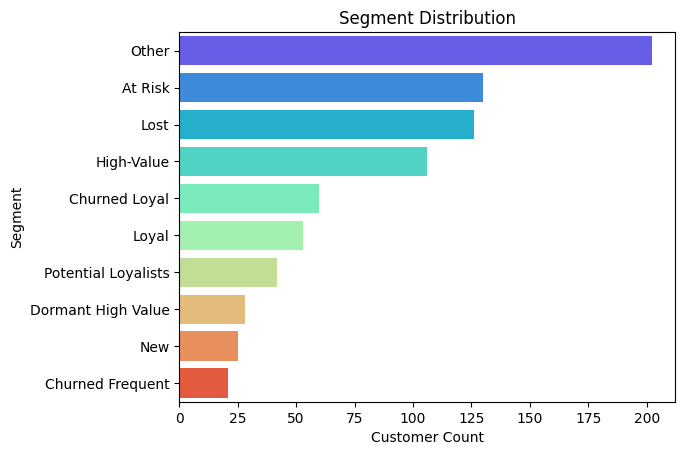

In [70]:
# Segment Distribution on a barplot

count = rfm['Segment'].value_counts().reset_index(name = 'Customer Count')
sns.barplot(data = count, y = 'Segment', hue = 'Segment', x = 'Customer Count', palette = 'rainbow', )
plt.title('Segment Distribution')
plt.show()

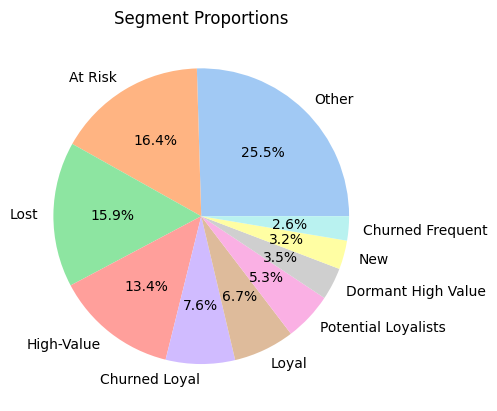

In [71]:
# Segment Proportions
count = rfm['Segment'].value_counts()
colors = sns.color_palette(palette = 'pastel', n_colors = len(data))
plt.pie(count, colors = colors, labels = count.index, autopct='%1.1f%%')
plt.title("Segment Proportions")
plt.show()

In [72]:
# Purchase Behaviour
rfm.groupby('Segment')['Monetary'].sum().round(2).sort_values(ascending=False).reset_index()

,Segment,Monetary
0,High-Value,561778.98
1,At Risk,524340.04
2,Churned Loyal,335695.17
3,Other,293204.44
4,Potential Loyalists,206315.37
5,Dormant High Value,125242.21
6,Loyal,112822.01
7,Lost,99826.28
8,Churned Frequent,27532.07
9,New,10444.31


In [73]:
# Engagement Frequency
rfm.groupby('Segment')['Frequency'].mean().round(2).sort_values(ascending=False).reset_index()

,Segment,Frequency
0,High-Value,19.83
1,Churned Loyal,19.33
2,Loyal,17.49
3,Churned Frequent,15.81
4,At Risk,15.62
5,Potential Loyalists,10.57
6,Other,9.20
7,Dormant High Value,8.64
8,Lost,6.09
9,New,5.20


In [74]:
# Segment-wise Profitability
rfm.groupby('Segment')['Profit'].agg(Total_Profit='sum',Avg_Profit='mean').round(2).sort_values(by='Avg_Profit',ascending=False).reset_index()

,Segment,Total_Profit,Avg_Profit
0,Potential Loyalists,43779.79,1042.38
1,Churned Loyal,49451.04,824.18
2,High-Value,63366.44,597.80
3,At Risk,66315.13,510.12
4,Dormant High Value,9431.90,336.85
5,Other,35748.03,176.97
6,Loyal,9110.66,171.90
7,Churned Frequent,2845.67,135.51
8,New,1586.76,63.47
9,Lost,4761.61,37.79


"Potential Loyalists" emerge as the most profitable customer segment, presenting a valuable opportunity to strengthen engagement and convert them into long-term loyal customers.

# Sales Forecasting Using Time Series Analysis

In [75]:
# Creating monthly sales table for forecatsing
monthly_data = df.groupby('Order month_year')['Sales'].sum().reset_index().sort_values(by = 'Order month_year', ignore_index = True)

# Converting the data type of month_year column to datetime
monthly_data['Order month_year'] = monthly_data['Order month_year'].dt.to_timestamp()

# Making the date column, index column
monthly_data.set_index('Order month_year', inplace = True)

In [76]:
monthly_data.head()

,Sales
Order month_year,
2014-01-01,14236.895
2014-02-01,4519.892
2014-03-01,55691.009
2014-04-01,28295.345
2014-05-01,23648.287


Using Holt-Winters Exponential Smoothing model as, historical data exhibits both a clear trend and distinct seasonal pattern.

In [77]:
# Creating train-test split
train = monthly_data.iloc[:36]
test = monthly_data.iloc[36:]

In [78]:
# Holt-Winters Model
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model= ExponentialSmoothing(train['Sales'], trend= 'add', seasonal= 'add', seasonal_periods= 12)

hw_model= model.fit()

predictions= hw_model.forecast(len(test))

C:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


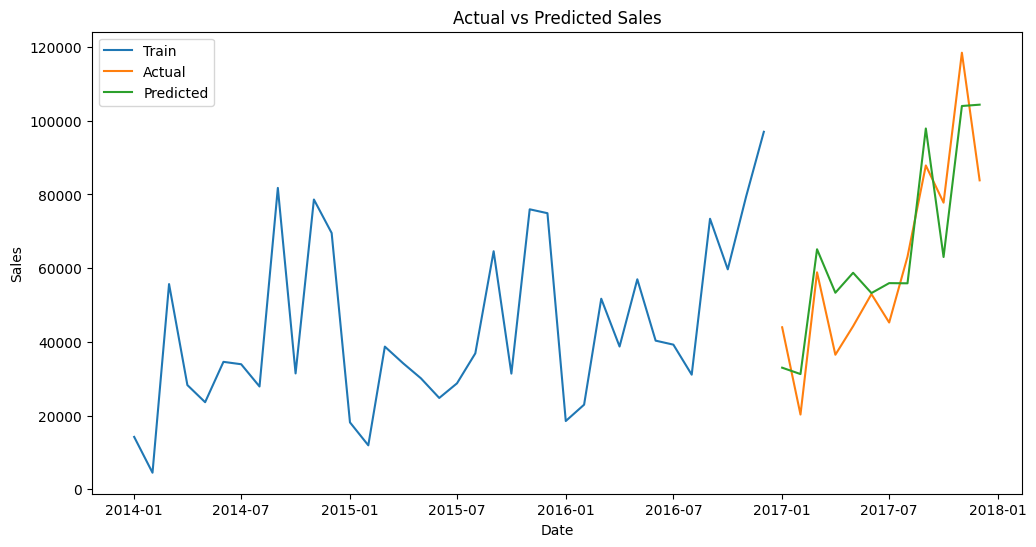

In [79]:
# Actual vs Predicted Sales
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Sales'], label='Train')
plt.plot(test.index, test['Sales'], label='Actual')
plt.plot(test.index, predictions, label='Predicted')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.show()

The model was able to capture the overall sales trend and seasonal patterns. While some high sales peaks were under-predicted.

In [80]:
# Calculating RMSE to check the model's prediction accuracy

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['Sales'], predictions))

print("RMSE:", round(rmse,2))

RMSE: 12540.9


In [81]:
test['Sales'].mean()

np.float64(61101.271266666656)

With a forecast error of 20.5%, the model provides a reasonable estimate of future sales patterns while maintaining acceptable predictive performance.

In [82]:
# Training the Final Exponential Smoothing Model
final_model = ExponentialSmoothing(
    monthly_data['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

C:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [83]:
# Calculating 6 months forecast
future_forecast = final_model.forecast(6)

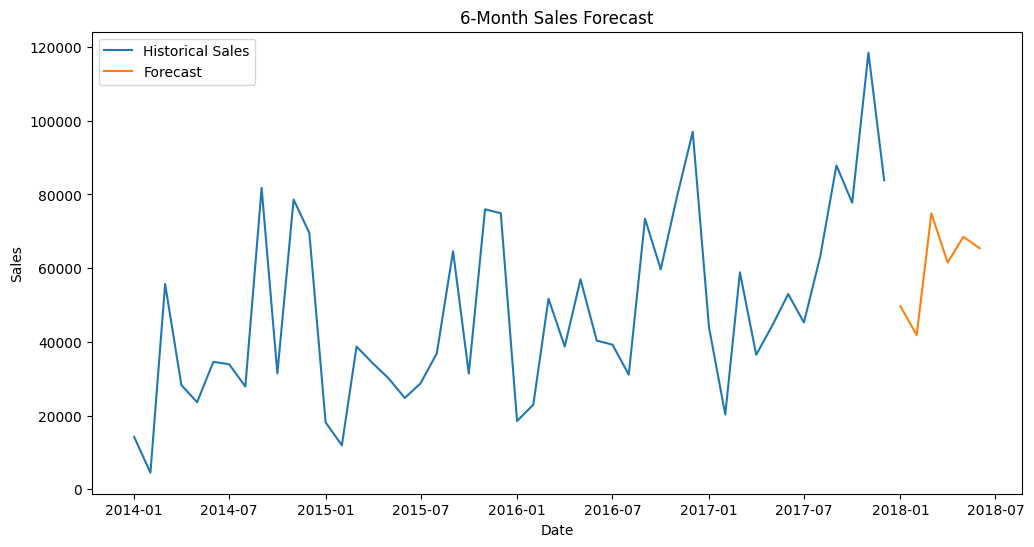

In [84]:
# 6-Month Sales Forecast Line Plot
plt.figure(figsize=(12,6))

plt.plot(monthly_data.index,
         monthly_data['Sales'],
         label='Historical Sales')

plt.plot(future_forecast.index,
         future_forecast,
         label='Forecast')

plt.title('6-Month Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()

plt.show()